# Preparation for interpolation. Parameters in $p_{\rm diff}(DM_{\rm diff})$

$ p_{\rm diff, \Delta}(\Delta)d\Delta=p_{\rm diff, DM}(DM)dDM$

$p_{\rm diff, DM}(DM)=A\frac{DM^{-\beta}}{<DM>^{-\beta-1}}\exp[-\frac{(DM^{-\alpha}-C_0 <DM>^{-\alpha})}{2\alpha \sigma^2 <DM>^{-2\alpha}}]$

$p_{\rm diff, DM}(DM)=\tilde{A}DM^{-\beta}\exp[-\frac{(DM^{-\alpha}-\tilde{C_0})}{2\alpha \tilde{\sigma}^2 }]$, where $\tilde{A}=A<DM>^{\beta+1}$, $\tilde{C_0}=\frac{C_0}{<DM>^{\alpha}}$, and $\tilde{\sigma}=\frac{\sigma}{<DM>^{\alpha}}$

In $p_{\rm diff, DM}(DM)$, $\tilde{A}$ is still the nomalization parameter. $\tilde{C_0}$ should be derive according to $\int DM\cdot p_{\rm diff, DM}(DM)dDM=<DM>$

Confidence interval version

In [3]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

# Preparation interpolation

search F range 

In [4]:
def find_C0_sigma_DM(sigma, x_min=0, x_max=np.inf, alpha=3, beta=3, condition='mean', analytical_value=1.0, initial_guess=None):
    """
    Use fsolve to find C_0 when to_C_0 = 1
    
    Parameters:
    -----------
    F: float - Structure factor parameter 
    z: float - Redshift
    alpha: float - Alpha parameter
    initial_guess: float - C_0 initial guess
    condition: condition choose from "mean", "median" or "mode" value equal to 1. For the median recommend minimum sigma from 0.3.
    analytical_value: float - Analytical value of F(p) to derive C_0, default is 1.0 for varable as \Delta. If take variable DM version please set as <DM>.
    
    Returns:
    --------
    float: C_0 or None if solution not found
    """
    if initial_guess==None:
        initial_guess = analytical_value
    
    if (condition=="mean"):
        def objective_function(C_0):
            result1,_= quad(lambda x: x*pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), x_min, x_max)
            result2,_= quad(lambda x: pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), x_min, x_max)
      
            return result1 - analytical_value * result2

    elif (condition=="median"):
        def objective_function(C_0):
        
            result,_= quad(lambda x: pdf_DM_cosmo(x, C_0, 1.0, sigma, alpha, beta), x_min, analytical_value)
            int,_= quad(lambda x: pdf_DM_cosmo(x, C_0, 1.0, sigma, alpha, beta), analytical_value, x_max)
    
            return result-int

    elif (condition=="mode"):
        def objective_function(C_0):
        
            criteria=C_0**2+4*alpha*beta*sigma**2
            d3=2/(C_0+np.sqrt(criteria))
    
            return d3-analytical_value

    else:
        print('Choose condition from["mean","median","mode"]')
        
    try:
        solution = fsolve(objective_function, [initial_guess], full_output=True)
    
        if solution[2] == 1:  # Check if solution is found
            return solution[0][0]
            
    except Exception as e:
        print(f"find_C0 error ({condition}), sigma={sigma}, error: {e}, initial_guess={initial_guess}, check input or change initial guess")
        return None

$ C_0$ from $C_0(\sigma)$ to $C_0(\sigma, <DM>)$. Will actually be 2D interpolation. 

Fix $<DM>$ for test.

In [ ]:
sigma_rsl = 1000
Sigmas = np.linspace(0.01, 6.0, sigma_rsl)
# Sigmas = np.linspace(0.01, 8, sigma_rsl)
print([np.min(Sigmas), np.max(Sigmas)])

C0s = np.zeros_like(Sigmas)
As = np.zeros_like(Sigmas)
Errors = np.zeros_like(Sigmas)

pbar = tqdm(Sigmas)
for i, sigma in enumerate(pbar):
    pbar.set_description(f"Processing sigma={sigma:.4f}")
    
    DM_th=300.0
    
    C0 = find_C0_sigma_DM(sigma,
                 condition='mean',
                 analytical_value=DM_th,
                 initial_guess=1.0
                  )
    C0s[i] = C0
    
    if C0==None:
        print(f"Warning: C0 is None for sigma={sigma:.4f}")
        A=None
        Errors[i] = None
    else:
        A = find_A_sigma(C_0=C0, sigma=sigma)
        As[i] = A
    
        def cdf(Delta):
            integral, _ = quad(lambda x: pdf_DM_cosmo(x, C_0=C0, A=A, sigma=sigma, alpha=3, beta=3), 1e-10, Delta)
            return integral
        
        sigma2=calc_confidence_interval_width(cdf=cdf, 
                                              target_prob= 0.6827 #0.9545 # 0.6827
                                              )

        Errors[i] = sigma2/2

[0.01, 6.0]


Processing sigma=0.0160:   0%|          | 1/1000 [00:00<10:26,  1.59it/s]

Processing sigma=0.0220:   0%|          | 2/1000 [00:01<10:10,  1.63it/s]

Processing sigma=0.0400:   0%|          | 5/1000 [00:01<04:59,  3.32it/s]

Processing sigma=0.0460:   1%|          | 6/1000 [00:02<04:39,  3.56it/s]

...

Processing sigma=0.2738:   4%|▍         | 44/1000 [00:13<05:29,  2.90it/s]

Processing sigma=0.2858:   5%|▍         | 46/1000 [00:13<05:12,  3.06it/s]

Processing sigma=0.2858:   5%|▍         | 46/1000 [00:13<04:44,  3.35it/s]

find_A error，pdf=0.0, C_0=91.34801382150768, sigma=0.28581581581581583, error: float division by zero


TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

In [ ]:
mask = ~pd.isnull(C0s) & ~pd.isnull(As) & ~pd.isnull(Errors)
C0s = C0s[mask]
As = As[mask]
Errors = Errors[mask]
Sigmas = Sigmas[mask]
print(len(Sigmas), len(C0s), len(As), len(Errors))

2000 2000 2000 2000


In [4]:
# sigma_rsl=5000
# # Sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
# Sigmas=np.linspace(0.1, 59.0, sigma_rsl)
# print([np.min(Sigmas),np.max(Sigmas)])
# C0s=np.zeros_like(Sigmas)
# As=np.zeros_like(Sigmas)
# Error_sqrt=np.zeros_like(Sigmas)
# for i, sigma in enumerate(Sigmas):
#     C0=C0_sigma(sigma)
#     C0s[i]=C0
#     A=find_A_sigma(C_0=C0, sigma=sigma)
#     As[i]=A
#     Error_sqrt[i]=np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

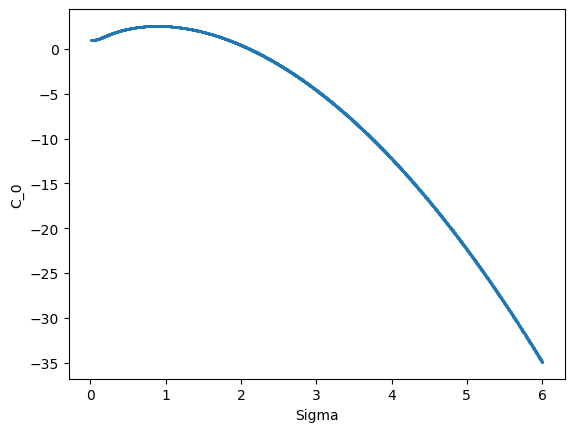

In [5]:
plt.scatter(Sigmas, C0s,  s=1)

plt.ylabel('C_0')
plt.xlabel('Sigma')
# plt.xlim(0,10)

plt.show()

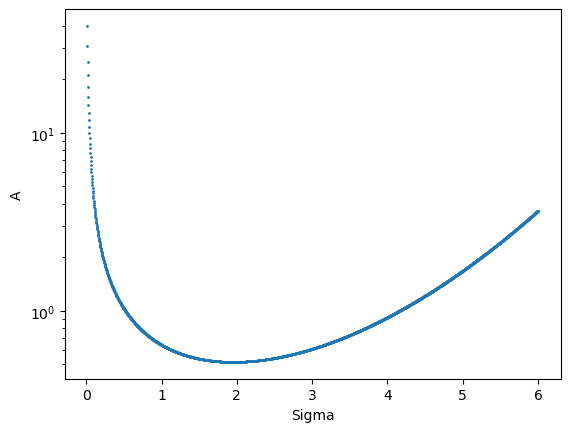

In [6]:
plt.scatter(Sigmas, As,  s=1)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
# plt.xlim(0,10)

plt.show()

Text(0.5, 0, 'Error')

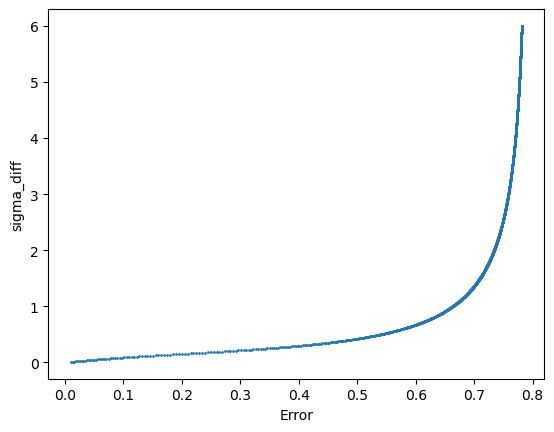

In [7]:
plt.scatter(Errors, Sigmas,s=1)
plt.ylabel('sigma_diff')
plt.xlabel('Error')
# plt.xlim(0.7, 0.8)
# plt.xscale('log')
# plt.yscale('log')

Text(0.5, 0, 'Sigma')

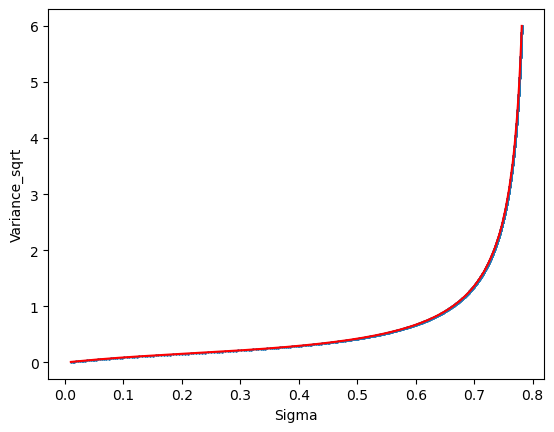

In [8]:
inter_sigma=interpolate.interp1d(Sigmas, Errors, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )
re_sigmas=np.linspace(np.min(Sigmas), np.max(Sigmas), 2*sigma_rsl)
re_var_sqrt=inter_sigma(re_sigmas)
plt.plot(re_var_sqrt, re_sigmas, 'r-', label='interpolated')
plt.scatter(Errors, Sigmas, s=1, label='original')
plt.ylabel('Variance_sqrt')
plt.xlabel('Sigma')

In [ ]:
np.savez('./interpolation/068_C0mean_pDM.npz', a=Sigmas, b=As, c=C0s, d=Errors)

In [ ]:
load_arrays=np.load('./interpolation/068_C0mean_pDM.npz')
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

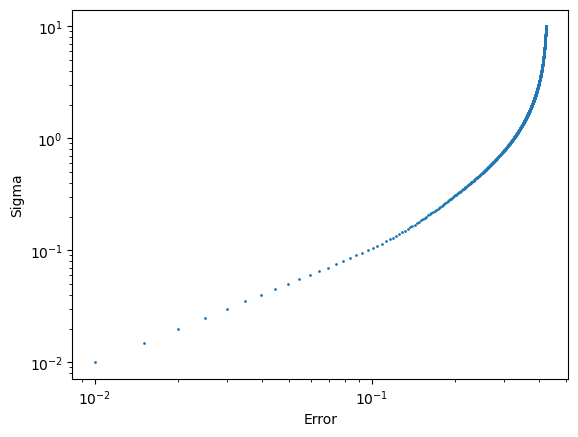

In [3]:
plt.scatter(Errors, Sigmas, s=1)
plt.ylabel('Sigma')
plt.xlabel('Error')
plt.xscale('log')
plt.yscale('log')

0.11904245825635151
0.12993996998499252


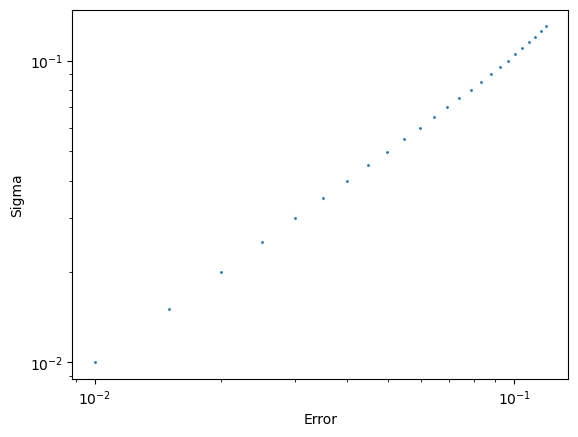

In [4]:
th=0.12
fit_error=Errors[Errors<=th]
fit_Sigmas=Sigmas[Errors<=th]
print(max(fit_error))
print(max(fit_Sigmas))
plt.scatter(fit_error, fit_Sigmas, s=1)
plt.ylabel('Sigma')
plt.xlabel('Error')
plt.xscale('log')
plt.yscale('log')

In [5]:
sigma=0.34
F=0.31
z=F/sigma
z=z**2
print(z)

0.8313148788927335


In [6]:
log_errors=np.log10(fit_error)
log_Sigmas=np.log10(fit_Sigmas)

def fit_fun(x, b):
    return x+b

popt, pcov = curve_fit(fit_fun, log_errors, log_Sigmas)
print(popt)
b=popt[0]
c=10**b
print(c)
print(10**0.30595)

[0.00992604]
1.0231187319438342
2.022786283394876


In [7]:
standard=np.sqrt(0.025)*c
print(np.sqrt(0.025+0.006)*c-standard)
print(standard)
print(standard-np.sqrt(0.025-0.008)*c)

0.018369365924389452
0.16176927548628936
0.028370913524366798


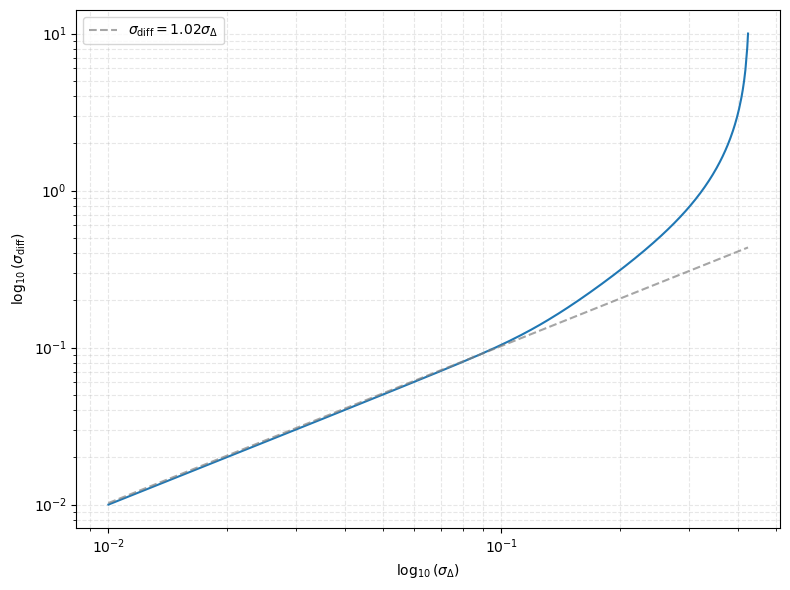

In [8]:
plt.figure(figsize=(8, 6))
# plt.scatter(Errors, Sigmas,s=0.5)
plt.plot(Errors, Sigmas)
plt.ylabel(r'$\log_{10} (\sigma_{\rm diff})$')
plt.xlabel(r'$\log_{10} (\sigma_\Delta)$')
plt.xscale('log',base=10)
plt.yscale('log',base=10)

x_min = min(Errors)
x_max = max(Errors)
x_range = np.logspace(np.log10(x_min), np.log10(x_max), 100)

const=10**b
y_ref = x_range * const
plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=r'$\sigma_{\rm diff} ='+f' {const:.2f}'+r'\sigma_\Delta $')

""" constants = [b-1, b-0.5, b, b+0.5, b+1]
for c in constants:
    const=(10**c)
    y_ref = x_range * const  # y = x * 10^c
    plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=r'$\sigma_{\rm diff} ='+f' ({const:.2e})'+r'\sigma_\Delta $') """

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('./plot/sigma_diff_vs_sigma_delta.pdf', dpi=300)

In [16]:
print(Errors)

[0.00999835 0.01499158 0.0199806  ... 0.42431991 0.4243219  0.42432883]


In [ ]:
# interpolation example

# C0_sigma = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# A_sigma = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# sigma_var = interpolate.interp1d(Error, Sigmas, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

In [ ]:
# np.save('./interpolation/Sigmas.npy', Sigmas)
# np.save('./interpolation/As.npy', As)
# np.save('./interpolation/C0s.npy', C0s)
# np.save('./interpolation/Errors.npy', Errors)